# Week 11: Retrieval-Augmented Generation (RAG)

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

We have covered pretraining, fine-tuning, and RLHF — all ways of baking knowledge into a model's weights. Today we look at a different approach: instead of teaching the model new facts, we **retrieve** relevant facts at query time and inject them into the prompt.

Objectives:

1) What RAG is and why it exists
2) The RAG pipeline: embed → index → retrieve → generate
3) Chunking strategies and their effect on retrieval quality
4) Hallucination: what happens when the answer is not in the corpus
5) Building a RAG system over congressional speeches

Code adapted from: LlamaIndex documentation, Lewis et al. (2020) RAG paper

In [1]:
!pip install -q llama-index llama-index-embeddings-huggingface transformers accelerate sentence-transformers
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
Dependencies installed.


---
## 1. What is RAG and Why Does it Exist?

All the models we have trained so far have one fundamental limitation: **they only know what was in their training data**. Once training ends, the knowledge is frozen in the weights.

This creates three problems:

| Problem | Example |
|---|---|
| **Stale knowledge** | GPT-2 was trained in 2019 — it knows nothing about events after that |
| **Private knowledge** | Your organisation's internal documents were never in the training set |
| **Hallucination** | When asked about something it doesn't know, the model confabulates |

**RAG** (Retrieval-Augmented Generation) solves this without retraining:

1. Store your documents in a **vector database** (indexed by meaning, not keywords)
2. At query time, **retrieve** the most relevant chunks
3. **Inject** those chunks into the LLM's prompt as context
4. The LLM **generates** an answer grounded in the retrieved text

The LLM does not need to memorise facts — it just needs to read and summarise. This is a much easier task, and it means you can update the knowledge base without touching the model.

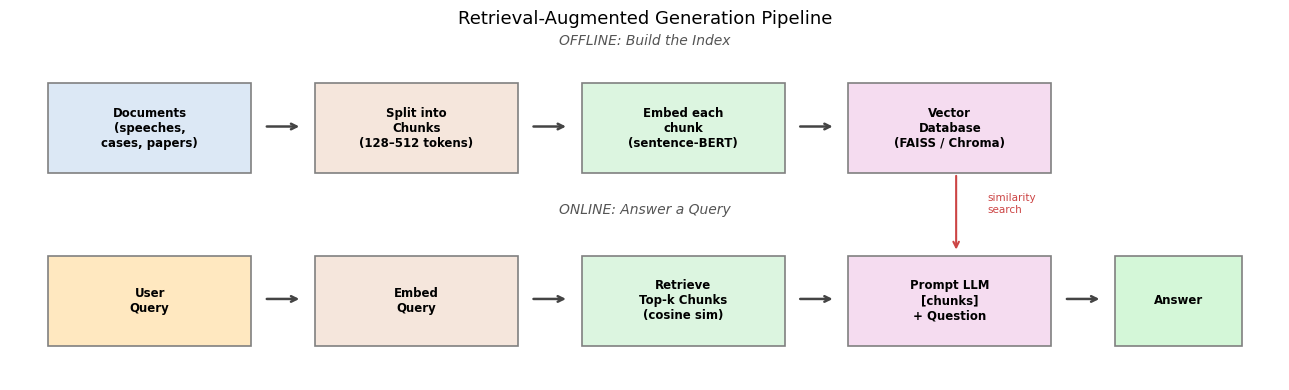

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Draw the RAG pipeline ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Offline (indexing) pipeline
ax.text(0.5, 0.97, 'OFFLINE: Build the Index', ha='center', fontsize=10,
        color='#555', style='italic')
offline_boxes = [
    (0.03, 0.60, 0.16, 0.26, 'Documents\n(speeches,\ncases, papers)', '#dce8f5'),
    (0.24, 0.60, 0.16, 0.26, 'Split into\nChunks\n(128–512 tokens)', '#f5e6dc'),
    (0.45, 0.60, 0.16, 0.26, 'Embed each\nchunk\n(sentence-BERT)', '#dcf5e0'),
    (0.66, 0.60, 0.16, 0.26, 'Vector\nDatabase\n(FAISS / Chroma)', '#f5dcf0'),
]
online_boxes = [
    (0.03, 0.10, 0.16, 0.26, 'User\nQuery', '#ffe8c0'),
    (0.24, 0.10, 0.16, 0.26, 'Embed\nQuery', '#f5e6dc'),
    (0.45, 0.10, 0.16, 0.26, 'Retrieve\nTop-k Chunks\n(cosine sim)', '#dcf5e0'),
    (0.66, 0.10, 0.16, 0.26, 'Prompt LLM\n[chunks]\n+ Question', '#f5dcf0'),
    (0.87, 0.10, 0.10, 0.26, 'Answer', '#d4f7d8'),
]
ax.text(0.5, 0.48, 'ONLINE: Answer a Query', ha='center', fontsize=10,
        color='#555', style='italic')

for boxes in [offline_boxes, online_boxes]:
    for x, y, w, h, txt, color in boxes:
        ax.add_patch(plt.Rectangle((x, y), w, h, color=color,
                                    ec='gray', lw=1.2, transform=ax.transAxes))
        ax.text(x+w/2, y+h/2, txt, ha='center', va='center',
                fontsize=8.5, transform=ax.transAxes, fontweight='bold')

for x in [0.20, 0.41, 0.62]:
    ax.annotate('', xy=(x+0.03, 0.735), xytext=(x, 0.735), xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', lw=1.8, color='#444'))
for x in [0.20, 0.41, 0.62, 0.83]:
    ax.annotate('', xy=(x+0.03, 0.235), xytext=(x, 0.235), xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', lw=1.8, color='#444'))

# Arrow from vector DB down to retrieval step
ax.annotate('', xy=(0.745, 0.37), xytext=(0.745, 0.60), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#c44',
                            connectionstyle='arc3,rad=0.0'))
ax.text(0.77, 0.485, 'similarity\nsearch', fontsize=7.5, color='#c44',
        transform=ax.transAxes)

ax.set_title('Retrieval-Augmented Generation Pipeline', fontsize=13, pad=8)
plt.tight_layout(); plt.show()

---
## 2. Building a RAG System over Congressional Speeches

We will build a RAG system that can answer questions about the content of US congressional floor speeches. This is exactly the kind of task where RAG shines: the corpus is too large to memorise, it changes over time (new speeches every session), and factual accuracy matters.

In [5]:
import pandas as pd
import torch
import numpy as np
from pathlib import Path

# Load the congressional speeches dataset
df = pd.read_csv('us_congress_speeches_sample.csv')
df['year'] = pd.to_datetime(df['date']).dt.year

print(f'Total speeches: {len(df):,}')
print(f'Date range: {df["year"].min()} - {df["year"].max()}')
print(f'Parties: {df["party"].value_counts().to_dict()}')
print(f'Chambers: {df["chamber"].value_counts().to_dict()}')
df[['date','party','chamber','text']].head(3)

Total speeches: 28,731
Date range: 1994 - 2024
Parties: {'Democrat': 15012, 'Republican': 13480, 'Independent': 234, 'Popular Democrat': 4, 'Libertarian': 1}
Chambers: {'House': 18909, 'Senate': 9822}


,date,party,chamber,text
0,2003-06-10,Democrat,House,"Mr. ISRAEL. Mr. Speaker, I rise today to com..."
1,2012-05-08,Democrat,House,"Mr. LANGEVIN. Mr. Speaker, Democrats are com..."
2,2010-03-25,Republican,House,"Mr. BISHOP of Utah. Mr. Speaker, Lori Garver..."


In [6]:
# ── Save a subset of speeches as text files for LlamaIndex ─────────────
# LlamaIndex's SimpleDirectoryReader expects text files in a folder
import os

os.makedirs('data/congress', exist_ok=True)

# Use 200 speeches — enough for meaningful retrieval, fast to index
sample = df.dropna(subset=['text']).sample(200, random_state=42).reset_index(drop=True)

for i, row in sample.iterrows():
    fname = f'data/congress/speech_{i:04d}_{row["party"][:3]}_{row["year"]}.txt'
    with open(fname, 'w', encoding='utf-8') as f:
        # Add metadata header so the LLM has context
        header = (f'Date: {row["date"]}\n'
                  f'Party: {row["party"]}\n'
                  f'Chamber: {row["chamber"]}\n\n')
        f.write(header + str(row['text']))

print(f'Saved {len(sample)} speeches to data/congress/')
print(f'Example file: {list(Path("data/congress").iterdir())[0].name}')

Saved 200 speeches to data/congress/
Example file: speech_0057_Rep_2007.txt


### Embedding model

BGE-small is fast, free, and strong for English text retrieval. It converts each text chunk into a 384-dimensional vector

In [7]:
import logging, sys
logging.basicConfig(stream=sys.stdout, level=logging.WARNING)  # suppress verbose logs

from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, Settings
from llama_index.core.node_parser import SentenceSplitter
from llama_index.embeddings.huggingface import HuggingFaceEmbedding


print('Loading embedding model...')
Settings.embed_model = HuggingFaceEmbedding(model_name='BAAI/bge-small-en-v1.5')
Settings.llm = None  # we handle generation ourselves

# ── Load documents ────────────────────────────────────────────────────────
documents = SimpleDirectoryReader('./data/congress').load_data()
print(f'Loaded {len(documents)} documents')
print(f'\nFirst 300 chars of doc 0:')
print(documents[0].text[:300])

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LLM is explicitly disabled. Using MockLLM.


Loaded 200 documents

First 300 chars of doc 0:
Date: 2006-09-20
Party: Democrat
Chamber: House

  Mr. OBERSTAR. Mr. Speaker, I yield myself such time as I may consume.
  Mr. Speaker, the gentleman from California and the gentleman from 
Pennsylvania have fully explained the provisions of this bill and the 
need for the project. It needs no furth


---
## 3. Chunking: The Most Important RAG Decision

Before indexing, documents must be split into **chunks** — short passages that fit within the embedding model's context window and are small enough to be precise when retrieved.

**Chunk size is a critical tradeoff:**

| Chunk size | Pros | Cons |
|---|---|---|
| Small (64–128 tokens) | Precise retrieval, specific facts | May lose surrounding context, fragments arguments |
| Medium (256–512 tokens) | Good balance | Standard choice |
| Large (512–1024 tokens) | Preserves context and argument flow | Noisy retrieval — irrelevant sentences included |

For congressional speeches, a medium chunk works well — speeches make arguments that span multiple sentences, so very small chunks fragment the reasoning.

In [8]:
# ── Compare different chunk sizes ────────────────────────────────────────
chunk_sizes = [64, 128, 256, 512]
results = {}

for chunk_size in chunk_sizes:
    parser = SentenceSplitter(chunk_size=chunk_size, chunk_overlap=20)
    nodes  = parser.get_nodes_from_documents(documents)
    token_lengths = [len(n.text.split()) for n in nodes]  # approx tokens via words
    results[chunk_size] = {
        'n_chunks': len(nodes),
        'avg_words': np.mean(token_lengths),
        'example': nodes[10].text[:200]
    }
    print(f'chunk_size={chunk_size:4d}  →  {len(nodes):5,} chunks  |  avg {np.mean(token_lengths):.0f} words/chunk')

print('\nExample chunk (size=128):')
print(results[128]['example'])

Metadata length (19) is close to chunk size (64). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (19) is close to chunk size (64). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (19) is close to chunk size (64). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (19) is close to chunk size (64). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (19) is close to chunk size (64). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
Metadata length (19) is close to chunk size (64). Resulting chunks are less than 50 tokens

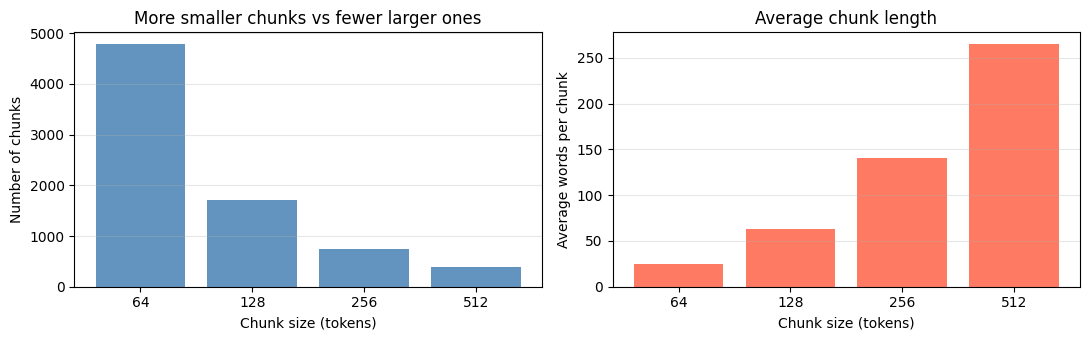

In [9]:
# ── Visualise chunk count vs size ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar([str(cs) for cs in chunk_sizes],
             [results[cs]['n_chunks'] for cs in chunk_sizes],
             color='steelblue', alpha=0.85)
axes[0].set_xlabel('Chunk size (tokens)')
axes[0].set_ylabel('Number of chunks')
axes[0].set_title('More smaller chunks vs fewer larger ones')
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar([str(cs) for cs in chunk_sizes],
             [results[cs]['avg_words'] for cs in chunk_sizes],
             color='tomato', alpha=0.85)
axes[1].set_xlabel('Chunk size (tokens)')
axes[1].set_ylabel('Average words per chunk')
axes[1].set_title('Average chunk length')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

---
## 4. Building the Vector Index and Retrieving

We embed every chunk and store the vectors in a **FAISS index** (LlamaIndex handles this automatically). At query time, we embed the question and find the chunks whose vectors are closest in meaning — **semantic search**, not keyword matching.

This is the key difference from simple `grep` or TF-IDF search: a chunk about 'reducing healthcare expenditure' will be retrieved by the query 'cutting medical costs' even though the words don't overlap.

In [10]:
from llama_index.core.retrievers import VectorIndexRetriever

# Build the index with chunk_size=256
print('Building vector index...')
parser = SentenceSplitter(chunk_size=256, chunk_overlap=30)
nodes  = parser.get_nodes_from_documents(documents)
index  = VectorStoreIndex(nodes)
print(f'Index built: {len(nodes):,} chunks embedded.')

Building vector index (this takes ~1 min for 200 speeches)...
Index built: 768 chunks embedded.


In [11]:
# ── Retrieve relevant chunks for a question ──────────────────────────────
retriever = VectorIndexRetriever(index=index, similarity_top_k=5)

query = 'What do Republican senators say about tax cuts?'
retrieved = retriever.retrieve(query)

print(f'Query: "{query}"')
print(f'Retrieved {len(retrieved)} chunks\n')
print('=' * 60)
for i, node in enumerate(retrieved):
    score = node.score if node.score else 'N/A'
    print(f'[Chunk {i+1}] similarity score: {score:.4f}')
    print(node.text[:300])
    print('-' * 60)

Query: "What do Republican senators say about tax cuts?"
Retrieved 5 chunks

[Chunk 1] similarity score: 0.7576
After all, 
while Republicans have for years been strongly advocating for 
comprehensive tax reform, encompassing both the individual and business 
tax systems, the President has only expressed a willingness to engage 
in tax reform on the business side. Indeed, he has more or less refused 
to even 
------------------------------------------------------------
[Chunk 2] similarity score: 0.7450
Date: 2013-04-24
Party: Democrat
Chamber: House

  Mr. JEFFRIES. I thank the gentleman from the Silver State for those 
very astute observations. As Representative Horsford has pointed out, a 
budget essentially is a choice and a pathway forward that people in 
this Chamber are making decisions on b
------------------------------------------------------------
[Chunk 3] similarity score: 0.7314
Date: 2014-12-16
Party: Republican
Chamber: Senate

  Mr. HATCH. The Senate will soon vote on 

In [12]:
# ── Semantic search vs keyword search ────────────────────────────────────
# Ask a semantically related question using different words than the corpus
queries = [
    'What arguments do members of Congress make about healthcare?',
    'How do legislators discuss economic inequality?',
    'What do senators say about military spending?',
]

print('Semantic retrieval — top chunk for each query:\n')
for q in queries:
    nodes_q = retriever.retrieve(q)
    print(f'Query: "{q}"')
    print(f'Best chunk (score={nodes_q[0].score:.4f}): {nodes_q[0].text[:200]}')
    print()

Semantic retrieval — top chunk for each query:

Query: "What arguments do members of Congress make about healthcare?"
Best chunk (score=0.7221): The AARP called the bill ``a bad deal for older Americans ages 50-
64,'' because it ``would significantly increase premiums for all older 
adults and spike costs dramatically for lower- and moderate-i

Query: "How do legislators discuss economic inequality?"
Best chunk (score=0.6869): Date: 2008-01-16
Party: Democrat
Chamber: House

  Mr. ALTMIRE. Madam Speaker, as Congress resumes this week, our 
priority must be to work in a bipartisan fashion to address our 
struggling economy.


Query: "What do senators say about military spending?"
Best chunk (score=0.7402): That is what the Senator says. 
But we can't have another way to do everything around here, another way 
to figure out what bills cost. We already have enough ways to figure 
them out, and they have g



---
## 5. Retrieval-Augmented Generation

Retrieval gives us the right passages. Now we pass them to an LLM with a structured prompt that says: **answer only from these sources, don't make things up**.

This is called the **RAG prompt template**. The critical instruction is telling the model to say 'I don't know' if the answer isn't in the provided sources — this is what prevents hallucination.

In [13]:
# ── RAG prompt template ──────────────────────────────────────────────────
RAG_PROMPT = (
    'You are an assistant that answers questions about US congressional speeches.\n'
    'Use ONLY the sources below to answer. If the answer is not in the sources, '
    'say "I cannot find this in the provided speeches."\n\n'
    '----- BEGIN SOURCES -----\n'
    '{sources}\n'
    '----- END SOURCES -----\n\n'
    'Question: {question}\n'
    'Answer:'
)

def build_rag_prompt(question, retrieved_nodes, max_chars_per_chunk=400):
    sources = []
    for i, node in enumerate(retrieved_nodes):
        text = node.text.replace('\n', ' ')[:max_chars_per_chunk]
        sources.append(f'[Source {i+1}] {text}')
    sources_block = '\n\n'.join(sources)
    return RAG_PROMPT.format(sources=sources_block, question=question)

# Complete prompt:
example_q   = 'What arguments do members of Congress make about healthcare?'
example_chunks = retriever.retrieve(example_q)
example_prompt = build_rag_prompt(example_q, example_chunks[:3])

print('Example RAG prompt (first 1200 chars):')
print('=' * 60)
print(example_prompt[:1200])
print('...')

Example RAG prompt (first 1200 chars):
You are an assistant that answers questions about US congressional speeches.
Use ONLY the sources below to answer. If the answer is not in the sources, say "I cannot find this in the provided speeches."

----- BEGIN SOURCES -----
[Source 1] The AARP called the bill ``a bad deal for older Americans ages 50- 64,'' because it ``would significantly increase premiums for all older  adults and spike costs dramatically for lower- and moderate-income  older adults.''   The AARP went on to state that the amendment that converted TrumpCare  1.0 into TrumpCare 2.0 was making ``a bad bill worse'' because it  ``establishes state waivers that allo

[Source 2] It is not simply about assisting struggling  families or hard-working or low-income families; it is also about  taking care of our seniors. She has a double challenge--her own care  and her husband's care. ``Without the ACA,'' she said, ``I surely will  die.''   Should that be the healthcare system we have

### Generating the answer

We have two options for the generation step:

**Option A — Use the OpenAI API** (requires an API key, gives best results)

**Option B — Use a local HuggingFace model** (free, runs on CPU, slower)

Both options use the exact same RAG prompt — the retrieval pipeline is independent of the LLM choice.

In [ ]:
from openai import OpenAI
client = OpenAI(api_key='')
#
def generate_answer_openai(prompt, model='gpt-3.5-turbo'):
    response = client.chat.completions.create(model=model,
                                              messages=[{'role': 'user', 'content': prompt}],
                                              max_tokens=300,
                                              temperature=0.2)
    return response.choices[0].message.content

In [18]:
# ── Run full RAG pipeline on several questions ───────────────────────────
questions = [
    'What arguments do members of Congress make about healthcare?',
    'How do Republican and Democratic speeches differ on tax policy?',
    'What do senators say about immigration?',
]

for question in questions:
    chunks  = retriever.retrieve(question)
    prompt  = build_rag_prompt(question, chunks[:3])
    answer  = generate_answer_openai(prompt)
    print(f'Q: {question}')
    print(f'A: {answer}')
    print(f'   [Based on {len(chunks)} retrieved chunks]')
    print()

Q: What arguments do members of Congress make about healthcare?
A: Members of Congress argue that the healthcare bill would significantly increase premiums for older Americans, spike costs for lower- and moderate-income older adults, endanger Americans' health, and prioritize benefits for the richest Americans.
   [Based on 5 retrieved chunks]

Q: How do Republican and Democratic speeches differ on tax policy?
A: Republicans strongly advocate for comprehensive tax reform encompassing both individual and business tax systems, while Democrats criticize the President for only expressing a willingness to engage in tax reform on the business side and refusing to talk about tax reform for individuals and families.
   [Based on 5 retrieved chunks]

Q: What do senators say about immigration?
A: Part of the discussion on immigration will be on a reliable employment verification program. People back home want employers to be held accountable. And, employers want to be responsible. People want to

---
## 6. Hallucination: What Happens When the Answer Isn't There

Hallucination is the central failure mode of LLMs: when they don't know something, they make it up with full confidence. RAG reduces this by grounding the model in retrieved text, but it doesn't eliminate it — the model can still hallucinate *from* the retrieved chunks.

Let's study this directly with two types of unanswerable questions.

In [20]:
# ── Type 1: Question completely outside the corpus ───────────────────────
# This tests whether the model respects the 'say I don't know' instruction

outside_questions = [
    'What did Senator Biden say about pizza toppings in 1998?',
    'How many times did Congress mention the word "unicorn" in 2015?',
]

print('Questions with NO correct answer in the corpus:')
print('=' * 60)
for question in outside_questions:
    chunks  = retriever.retrieve(question)
    prompt  = build_rag_prompt(question, chunks[:3])
    answer  = generate_answer_openai(prompt)
    print(f'Q: {question}')
    print(f'A: {answer}')
    print(f'Top retrieved chunk: {chunks[0].text[:150]}...')
    print()

Questions with NO correct answer in the corpus:
Q: What did Senator Biden say about pizza toppings in 1998?
A: I cannot find this in the provided speeches.
Top retrieved chunk: Date: 1996-07-12
Party: Democrat
Chamber: House

  Mr. STUDDS. Mr. Chairman, earlier this morning, I think somewhere 
around a quarter of two, I obser...

Q: How many times did Congress mention the word "unicorn" in 2015?
A: I cannot find this in the provided speeches.
Top retrieved chunk: That is the only 
reaction that honors our ``we the people'' government. That is the only 
action that would honor the promises that President Trump m...



In [23]:
# ── Type 2: Compare RAG vs no-RAG on the same question ──────────────────
# Shows what the model says without retrieved context (pure parametric memory)

question = 'What specific arguments did Congress make about the Affordable Care Act?'

# Without RAG: ask the model directly
bare_prompt  = f'Question: {question}\nAnswer:'
bare_answer  = generate_answer_openai(bare_prompt)

# With RAG: retrieve + inject context
chunks       = retriever.retrieve(question)
rag_prompt   = build_rag_prompt(question, chunks[:4])
rag_answer   = generate_answer_openai(rag_prompt)

print('Question:', question)
print()
print('WITHOUT RAG (parametric memory only):')
print(bare_answer)
print()
print('WITH RAG (grounded in retrieved speeches):')
print(rag_answer)
print()
print('Retrieved sources:')
for i, c in enumerate(chunks[:2]):
    print(f'  [{i+1}] {c.text[:200]}')

Question: What specific arguments did Congress make about the Affordable Care Act?

WITHOUT RAG (parametric memory only):
1. Congress argued that the Affordable Care Act would expand access to affordable health insurance coverage for millions of Americans who were previously uninsured or underinsured.

2. They argued that the ACA would help lower healthcare costs by implementing measures such as subsidies for low-income individuals and families, expanding Medicaid coverage, and implementing regulations to prevent insurance companies from denying coverage based on pre-existing conditions.

3. Congress also argued that the ACA would improve the overall quality of healthcare in the United States by implementing measures to promote preventive care, improve care coordination, and reduce medical errors.

4. They emphasized that the ACA would provide essential health benefits to all Americans, including coverage for preventive services, prescription drugs, maternity care, mental health servic

---
## 7. How Chunk Size Affects Answer Quality

Let's directly compare answers produced by RAG systems built with different chunk sizes on the same question. This makes the abstract tradeoff from Section 3 concrete.

In [26]:
# ── Build three indices with different chunk sizes ────────────────────────
print('Building indices for chunk sizes 64, 256, 512...')
indices = {}
for chunk_size in [256, 512]:
    parser_c = SentenceSplitter(chunk_size=chunk_size, chunk_overlap=10)
    nodes_c  = parser_c.get_nodes_from_documents(documents)
    indices[chunk_size] = VectorStoreIndex(nodes_c)
    print(f'  chunk_size={chunk_size}: {len(nodes_c)} chunks')

question = 'What economic arguments do senators make about tax reform?'

print(f'\nQuestion: "{question}"\n')
print('=' * 60)

for chunk_size, idx in indices.items():
    ret = VectorIndexRetriever(index=idx, similarity_top_k=3)
    chunks = ret.retrieve(question)
    prompt = build_rag_prompt(question, chunks)
    answer = generate_answer_openai(prompt)
    print(f'chunk_size={chunk_size}:')
    print(f'  Answer: {answer}')
    print(f'  Top chunk ({len(chunks[0].text.split())} words): {chunks[0].text[:150]}...')
    print()

Building indices for chunk sizes 64, 256, 512...
  chunk_size=256: 748 chunks
  chunk_size=512: 393 chunks

Question: "What economic arguments do senators make about tax reform?"

chunk_size=256:
  Answer: I cannot find this in the provided speeches.
  Top chunk (182 words): Indeed, he has more or less refused 
to even talk about tax reform for individuals and families, unless, of 
course, such reform amounted to a massive...

chunk_size=512:
  Answer: I cannot find this in the provided speeches.
  Top chunk (344 words): This is clearly 
not sound fiscal policy. It's the misguided policy of economic 
fairness, and it is just as Frederic Bastiat stated in his essay, ``T...

